Name: Christopher A. Lee\
Date: 04/04/2026\
Prof: Dr. Azarnoosh\
Course: Machine Learning for Data Analysis - ENBC 321

In [1]:
# Libraries
import random
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import scipy
scipy.interp = np.interp
import scikitplot as skplt

random.seed(321)

In [2]:
# Dataset
df = pd.read_csv('medical_data.csv')
print(df.head())

   Age  Blood_Pressure  Cholesterol  Glucose  Diagnosis
0   58           141.3        162.1    179.7          1
1   71           136.9        205.4    190.9          1
2   48           176.5        186.3     79.2          1
3   34           166.0        270.5     97.2          1
4   62           157.3        220.5    157.2          0


              AUC
Log Reg  0.500000
Ran For  0.468750
SVC      0.468750
KNN      0.515625

Cap Curves


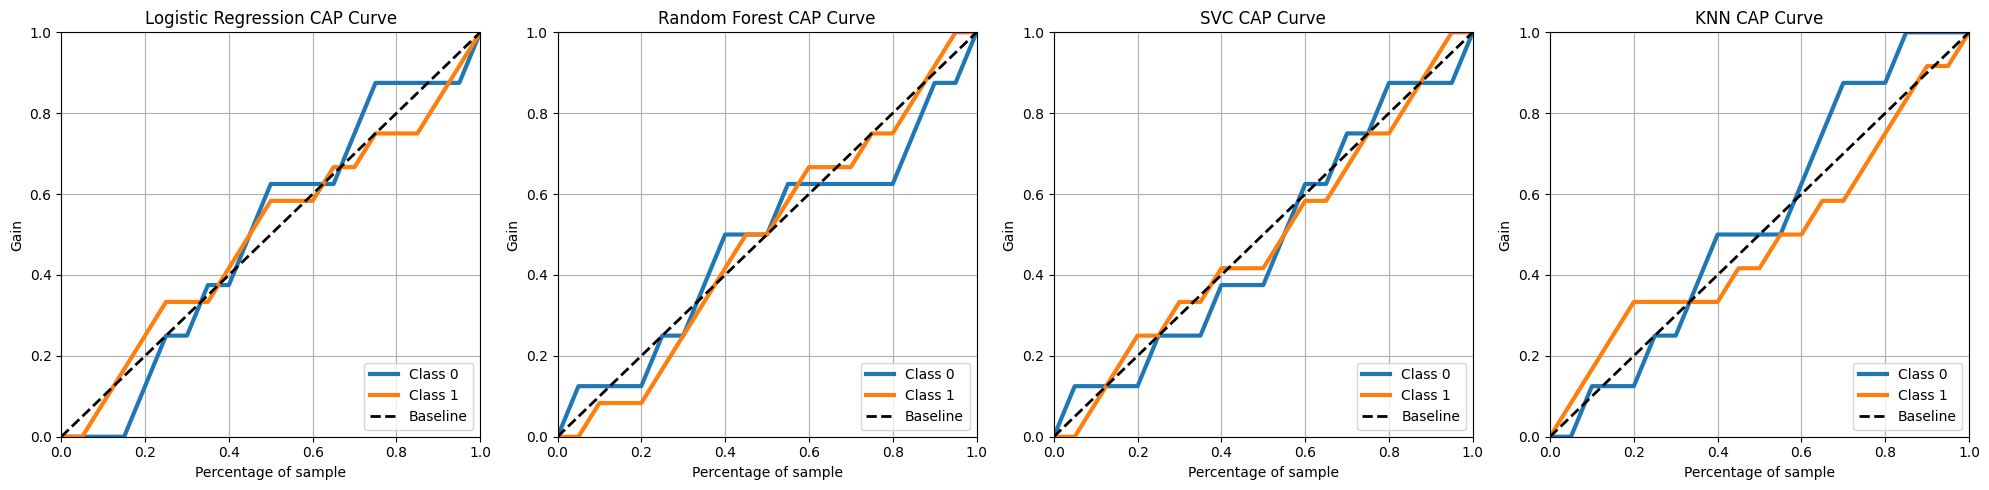

In [3]:
# Results Dataframe
df_metrics = pd.DataFrame({}, index=['Log Reg', 'Ran For', 'SVC', 'KNN'])

# Data Preparation
X, y = df[['Age', 'Blood_Pressure', 'Cholesterol', 'Glucose']], df['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Implementation
# Logistic Regression
model_log = LogisticRegression().fit(X_train, y_train)
model_log_pred = model_log.predict_proba(X_test)
df_metrics.at['Log Reg', 'AUC'] = roc_auc_score(y_test, model_log_pred[:, 1])
# Random Forest
model_rf = RandomForestClassifier().fit(X_train, y_train)
model_rf_pred = model_rf.predict_proba(X_test)
df_metrics.at['Ran For', 'AUC'] = roc_auc_score(y_test, model_rf_pred[:, 1])
# SVC
model_svc = SVC(probability=True).fit(X_train, y_train)
model_svc_pred = model_svc.predict_proba(X_test)
df_metrics.at['SVC', 'AUC'] = roc_auc_score(y_test, model_svc_pred[:, 1])
# KNN
model_knn = KNeighborsClassifier().fit(X_train, y_train)
model_knn_pred = model_knn.predict_proba(X_test)
df_metrics.at['KNN', 'AUC'] = roc_auc_score(y_test, model_knn_pred[:, 1])

# Print Results
print(df_metrics)

print("\nCap Curves")
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
skplt.metrics.plot_cumulative_gain(y_test, model_log_pred, title='Logistic Regression CAP Curve', ax=axes[0])
skplt.metrics.plot_cumulative_gain(y_test, model_rf_pred, title='Random Forest CAP Curve', ax=axes[1])
skplt.metrics.plot_cumulative_gain(y_test, model_svc_pred, title='SVC CAP Curve', ax=axes[2])
skplt.metrics.plot_cumulative_gain(y_test, model_knn_pred, title='KNN CAP Curve', ax=axes[3])
plt.tight_layout()
plt.show()

In [4]:
print('1. KNN performed the best due to its highest AUC score and visually shown to align the with the \nCAP curve the most.')
print('2. Even though the higher AUC for the KNN model indicates better overall disease detection across \nall thresholds, it is not always preferable in healthcare if the model is unable to detect true \npositives at a higher rate.')
print('3. The AUC measures the probability of correctly ranking a sick patient higher than a healthy one. \n0.5 means random guessing, 0.7 is an alright predictive ability, and 1.0 is perfect guessing.')
print('4. The CAP curve is a usfeul tool because it shows exactly what percentage of sick patients you \nwill successfully identify if you can only test high risk individuals.')
print('5. ROC curve evaluates trade off bewteen ture and false positive rates while the CAP curve plots \ncumulative cases against the tested population.')

1. KNN performed the best due to its highest AUC score and visually shown to align the with the 
CAP curve the most.
2. Even though the higher AUC for the KNN model indicates better overall disease detection across 
all thresholds, it is not always preferable in healthcare if the model is unable to detect true 
positives at a higher rate.
3. The AUC measures the probability of correctly ranking a sick patient higher than a healthy one. 
0.5 means random guessing, 0.7 is an alright predictive ability, and 1.0 is perfect guessing.
4. The CAP curve is a usfeul tool because it shows exactly what percentage of sick patients you 
will successfully identify if you can only test high risk individuals.
5. ROC curve evaluates trade off bewteen ture and false positive rates while the CAP curve plots 
cumulative cases against the tested population.
